### Exploratory Data Analysis (EDA)

1. libraries import

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. loading the dataset 

In [ ]:
df = pd.read_csv('data/raw_data/car_price.csv', low_memory=False)

3. questioning the data

In [12]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [15]:
# How many rows and columns does the dataset have?
print(f'shape: {df.shape}')

shape: (2500, 10)


In [20]:
# Which features are numerical? Which are categorical?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


In [22]:
# Are there any missing values? How many, and in which columns?
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

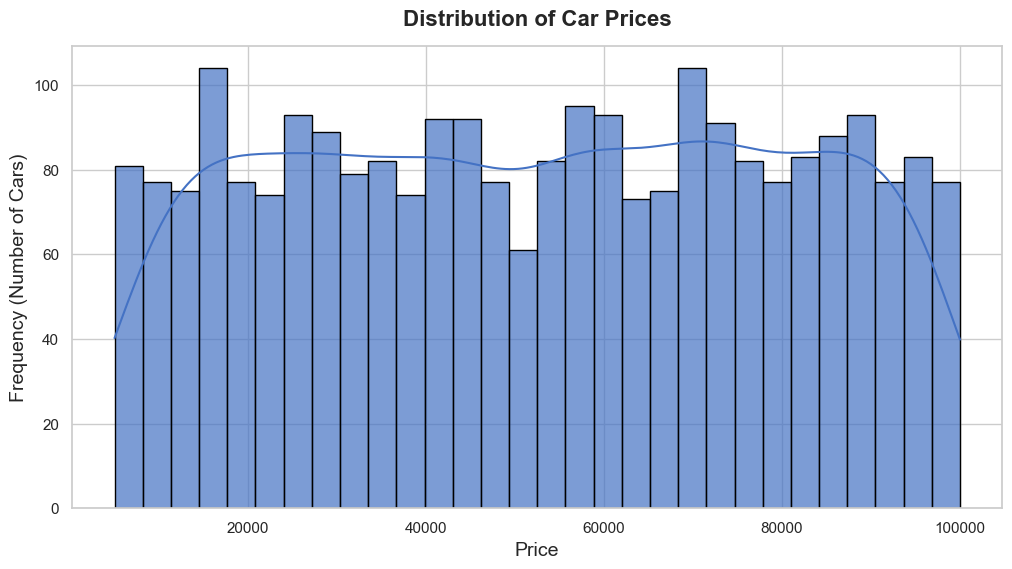

In [49]:
# What does the distribution of car prices look like?

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(df['Price'], bins=30, kde=True, color="#4472c4", edgecolor="black", alpha=0.7)

plt.title('Distribution of Car Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency (Number of Cars)', fontsize=14)

plt.show()

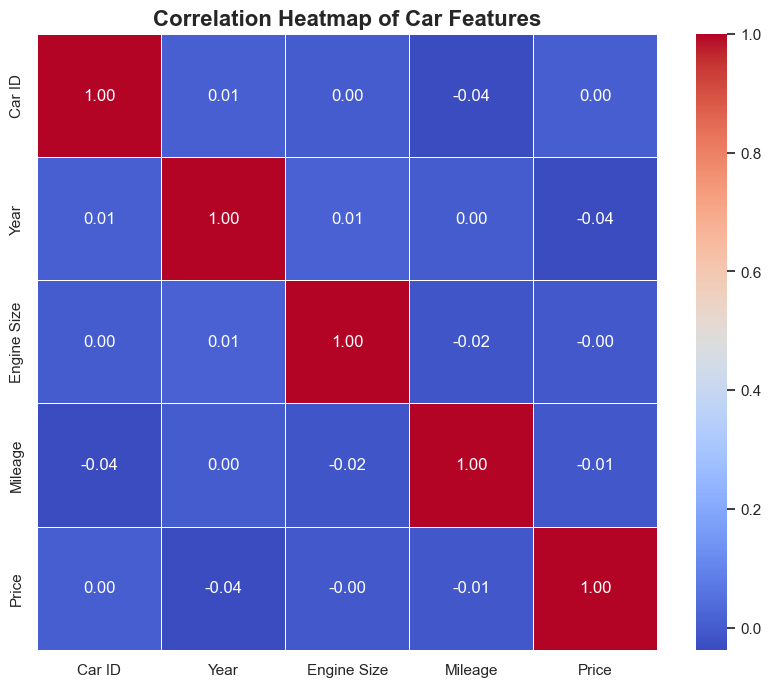

Features most related to price:
Price          1.000000
Car ID         0.004650
Engine Size   -0.004420
Mileage       -0.008567
Year          -0.036805
Name: Price, dtype: float64


In [45]:
# Which features seem most related to price؟

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Correlation Heatmap of Car Features', fontsize=16, fontweight='bold')
plt.show()

print("Features most related to price:")
print(correlation_matrix['Price'].sort_values(ascending=False))